In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
BASE_PATH = 'dataset'
MODELS = os.path.join(BASE_PATH, 'models')
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
DATASET = os.path.join(BASE_PATH, 'dataset_produksi_padi.csv')

os.makedirs(os.path.join(MODELS, 'k-fold'), exist_ok=True)

In [3]:
df = pd.read_csv(DATASET)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2545 entries, 0 to 2544
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           2545 non-null   object 
 1   luas_panen          2545 non-null   float64
 2   produktivitas       2545 non-null   float64
 3   produksi            2545 non-null   float64
 4   tahun               2545 non-null   int64  
 5   provinsi            2545 non-null   object 
 6   curah_hujan_rataan  2545 non-null   float64
 7   curah_hujan_total   2545 non-null   float64
 8   suhu_rataan         2545 non-null   float64
 9   suhu_maksimum       2545 non-null   float64
 10  suhu_minimum        2545 non-null   float64
 11  kelembapan_rataan   2545 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 238.7+ KB


In [5]:
X = df.drop(columns=['kabupaten', 'produksi', 'produktivitas', 'provinsi'])
y = df['produksi']

In [6]:
X_arr = X.to_numpy()
y_arr = y.to_numpy()

# 2. Inisialisasi K-Fold (Misal 10 Lipatan)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scaler = StandardScaler()
model_lr = LinearRegression()

# List untuk menampung skor dari setiap lipatan (fold)
mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

# Variabel untuk menampung prediksi keseluruhan data
y_all_true = []
y_all_pred = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_arr), 1):
    # Memisahkan data train dan data validasi pada fold saat ini
    X_train_f, X_val_f = X_arr[train_idx], X_arr[val_idx]
    y_train_f, y_val_f = y_arr[train_idx], y_arr[val_idx]
    
    # Normalisasi Fitur
    X_train_f_scaled = scaler.fit_transform(X_train_f)
    X_val_f_scaled = scaler.transform(X_val_f)
    
    # Training Model
    model_lr.fit(X_train_f_scaled, y_train_f)
    
    # Prediksi
    y_pred_f = model_lr.predict(X_val_f_scaled)
    
    # Hitung metrik pada fold saat ini
    f_mae = mean_absolute_error(y_val_f, y_pred_f)
    f_mse = mean_squared_error(y_val_f, y_pred_f)
    f_rmse = np.sqrt(f_mse)
    f_r2 = r2_score(y_val_f, y_pred_f)
    
    # Simpan hasil per fold
    mae_scores.append(f_mae)
    mse_scores.append(f_mse)
    rmse_scores.append(f_rmse)
    r2_scores.append(f_r2)
    
    # Simpan nilai asli vs prediksi untuk visualisasi akhir
    y_all_true.extend(y_val_f)
    y_all_pred.extend(y_pred_f)
    
    print(f"Fold {fold} -> MAE: {f_mae:.2f} | RMSE: {f_rmse:.2f} | R2: {f_r2:.4f}")

Fold 1 -> MAE: 19209.27 | RMSE: 32417.77 | R2: 0.9741
Fold 2 -> MAE: 17293.52 | RMSE: 32587.71 | R2: 0.9791
Fold 3 -> MAE: 19172.39 | RMSE: 33091.95 | R2: 0.9762
Fold 4 -> MAE: 19942.72 | RMSE: 35338.63 | R2: 0.9762
Fold 5 -> MAE: 19312.31 | RMSE: 31818.14 | R2: 0.9764
Fold 6 -> MAE: 16757.92 | RMSE: 25985.46 | R2: 0.9826
Fold 7 -> MAE: 20454.23 | RMSE: 37703.22 | R2: 0.9728
Fold 8 -> MAE: 17477.05 | RMSE: 28680.19 | R2: 0.9798
Fold 9 -> MAE: 19229.68 | RMSE: 29678.23 | R2: 0.9826
Fold 10 -> MAE: 18625.49 | RMSE: 30863.84 | R2: 0.9810


In [7]:
print("=== RATA-RATA EVALUASI K-FOLD MODEL LINEAR REGRESSION ===")
print(f"Rata-rata MAE  : {np.mean(mae_scores):.2f}")    
print(f"Rata-rata RMSE : {np.mean(rmse_scores):.2f}")
print(f"Rata-rata R2   : {np.mean(r2_scores):.4f} (atau {np.mean(r2_scores)*100:.1f}%)")

=== RATA-RATA EVALUASI K-FOLD MODEL LINEAR REGRESSION ===
Rata-rata MAE  : 18747.46
Rata-rata RMSE : 31816.51
Rata-rata R2   : 0.9781 (atau 97.8%)


In [8]:
joblib.dump(model_lr, os.path.join(MODELS,'k-fold/model_k_fold_linear_regression_final.joblib'))
joblib.dump(scaler, os.path.join(MODELS,'k-fold/scaler_k_fold_final.joblib'))

print("Model Final dan Scaler berhasil disimpan dalam format .joblib!")

Model Final dan Scaler berhasil disimpan dalam format .joblib!


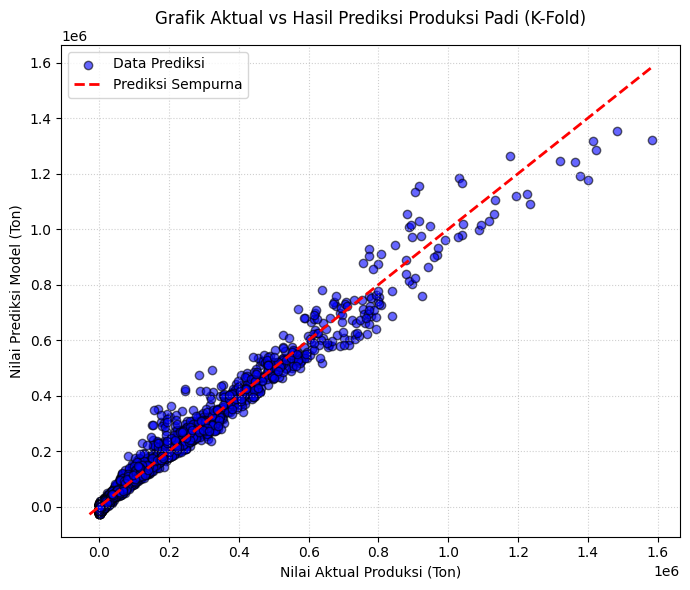

In [9]:
# Plot Nilai Aktual vs Hasil Prediksi Model
plt.figure(figsize=(7, 6))
plt.scatter(y_all_true, y_all_pred, color='blue', alpha=0.6, edgecolors='k', label='Data Prediksi')

# Garis diagonal bantu linearitas sempurna
max_val = max(max(y_all_true), max(y_all_pred))
min_val = min(min(y_all_true), min(y_all_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prediksi Sempurna')

plt.title('Grafik Aktual vs Hasil Prediksi Produksi Padi (K-Fold)', fontsize=12, pad=15)
plt.xlabel('Nilai Aktual Produksi (Ton)', fontsize=10)
plt.ylabel('Nilai Prediksi Model (Ton)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE,'k-fold/matriks_korelasi_final.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

In [10]:
threshold = np.mean(y_all_true)

# 2. Konversi nilai aktual dan prediksi kontinu menjadi kategori biner (0 atau 1)
# 0 = Produksi Di Bawah Rata-rata (Rendah)
# 1 = Produksi Di Atas/Sama Dengan Rata-rata (Tinggi)
y_true_classified = np.where(np.array(y_all_true) >= threshold, 1, 0)
y_pred_classified = np.where(np.array(y_all_pred) >= threshold, 1, 0)

cm = confusion_matrix(y_true_classified, y_pred_classified)
accuracy = accuracy_score(y_true_classified, y_pred_classified)

print("=== EVALUASI KATEGORIKAL ===")
print(f"Ambang Batas Produksi Rata-rata: {threshold:.2f} Ton\n")
print(f"Akurasi Kategorikal: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true_classified, y_pred_classified, 
                            target_names=['Produksi Rendah', 'Produksi Tinggi']))

=== EVALUASI KATEGORIKAL ===
Ambang Batas Produksi Rata-rata: 153921.09 Ton

Akurasi Kategorikal: 97.88%

Classification Report:
                 precision    recall  f1-score   support

Produksi Rendah       0.99      0.98      0.98      1703
Produksi Tinggi       0.95      0.98      0.97       842

       accuracy                           0.98      2545
      macro avg       0.97      0.98      0.98      2545
   weighted avg       0.98      0.98      0.98      2545



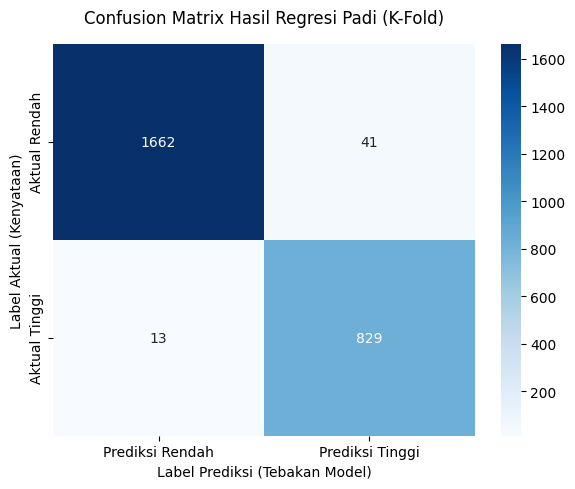

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Prediksi Rendah', 'Prediksi Tinggi'],
    yticklabels=['Aktual Rendah', 'Aktual Tinggi']
)

plt.title('Confusion Matrix Hasil Regresi Padi (K-Fold)', fontsize=12, pad=15)
plt.ylabel('Label Aktual (Kenyataan)', fontsize=10)
plt.xlabel('Label Prediksi (Tebakan Model)', fontsize=10)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE,'k-fold/confusion_matrix_final.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()